In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from collections import Counter
import random


In [2]:
DATA_DIR = "../data/"
df = pd.read_csv(DATA_DIR + "train.csv")
df.head()

,ImageId,MaskId
0,ID00007637202177411956430_0.jpg,ID00007637202177411956430_mask_0.jpg
1,ID00007637202177411956430_1.jpg,ID00007637202177411956430_mask_1.jpg
2,ID00007637202177411956430_2.jpg,ID00007637202177411956430_mask_2.jpg
3,ID00007637202177411956430_3.jpg,ID00007637202177411956430_mask_3.jpg
4,ID00007637202177411956430_4.jpg,ID00007637202177411956430_mask_4.jpg


In [ ]:
img_shape_counter = Counter()
img_channels_counter = Counter()

mask_shape_counter = Counter()
mask_channels_counter = Counter()

empty_masks = 0
missing_files = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = DATA_DIR + "images/images/" + row['ImageId']
    mask_path = DATA_DIR + "masks/masks/" + row['MaskId']

    # Load images and masks
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # Check for missing files
    if img is None or mask is None:
        missing_files += 1
        continue

    # Update image shape and channel counters

    #Image
    img_shape_counter[img.shape] += 1
    if len(img.shape) == 2:
        img_channels_counter[1] += 1
    else:
        img_channels_counter[img.shape[2]] += 1

    #Mask
    mask_shape_counter[mask.shape] += 1
    if len(mask.shape) == 2:
        mask_channels_counter[1] += 1
    else:
        mask_channels_counter[mask.shape[2]] += 1
    
    # Empty mask check
    if np.all(mask == 0):
        empty_masks += 1


# Summary of findings
print("Missing files:", missing_files)

print("\nIMG shapes (top 5):")
for k, v in img_shape_counter.most_common(5):
    print(k, v)
print("IMG channels:", img_channels_counter)

print("\nMASK shapes (top 5):")
for k, v in mask_shape_counter.most_common(5):
    print(k, v)
print("MASK channels:", mask_channels_counter)

print(f"\nEmpty masks: {empty_masks}/{len(df)} ({empty_masks/len(df):.2%})")

100%|██████████| 16708/16708 [05:21<00:00, 52.04it/s]

Missing files: 0

IMG shapes (top 5):
(512, 512) 16708
IMG channels: Counter({1: 16708})

MASK shapes (top 5):
(512, 512, 3) 16708
MASK channels: Counter({3: 16708})

Empty masks: 2274/16708 (13.61%)

Mask values seen (top 20): [(np.uint8(0), 16708), (np.uint8(1), 14434), (np.uint8(2), 14434), (np.uint8(3), 14434), (np.uint8(4), 14434), (np.uint8(5), 14434), (np.uint8(6), 14434), (np.uint8(7), 14434), (np.uint8(9), 14434), (np.uint8(12), 14434), (np.uint8(11), 14433), (np.uint8(14), 14432), (np.uint8(8), 14431), (np.uint8(16), 14429), (np.uint8(13), 14424), (np.uint8(10), 14422), (np.uint8(18), 14422), (np.uint8(19), 14414), (np.uint8(15), 14411), (np.uint8(21), 14410)]


Con este análisis se puede observar que las imágenes están en 2D en una escala de grises y con dimensiones de 512x512. Además, las máscaras se encuentran en 3D, multicanal, es decir, las 3 clases (corazón, pulmones y traquea) están representadas en cada uno de los canales.

Por último, podemos ver que al rededor de 14% de los datos no presentan ninguna de las clases objetivo.

In [24]:
# Definimos los canales y le asignamos colores específicos
# Con esto se puede escoger un ejemplo que cuente con los 3 canales y visualizar un buen ejemplo

def has_red(mask_rgb, thr=200, low=80):
    r,g,b = mask_rgb[:,:,0], mask_rgb[:,:,1], mask_rgb[:,:,2]
    return np.any((r >= thr) & (g <= low) & (b <= low))

def has_green(mask_rgb, thr=200, low=80):
    r,g,b = mask_rgb[:,:,0], mask_rgb[:,:,1], mask_rgb[:,:,2]
    return np.any((g >= thr) & (r <= low) & (b <= low))

def has_blue(mask_rgb, thr=200, low=80):
    r,g,b = mask_rgb[:,:,0], mask_rgb[:,:,1], mask_rgb[:,:,2]
    return np.any((b >= thr) & (r <= low) & (g <= low))

In [34]:
proper_example = None
while proper_example is None:
    i = random.randint(0, len(df) - 1)
    img_path = DATA_DIR + "images/images/" + df.iloc[i]['ImageId']
    mask_path = DATA_DIR + "masks/masks/" + df.iloc[i]['MaskId']

    # Combrobar que el archivo existe
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image file not found: {img_path}")
    mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    if mask is None:
        raise FileNotFoundError(f"Mask file not found: {mask_path}")
    
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    red = has_red(mask_rgb)
    green = has_green(mask_rgb)
    blue = has_blue(mask_rgb)

    # Comprobar por cada canal si tiene algún valor distinto de cero
    if red and green and blue:
        proper_example = (img, mask_rgb)
        print(f"Image shape: {img.shape}, min/max: {img.min()}/{img.max()}")
        print(f"Mask shape: {mask_rgb.shape}, min/max: {mask_rgb.min()}/{mask_rgb.max()}")


Image shape: (512, 512), min/max: 0/255
Mask shape: (512, 512, 3), min/max: 0/255


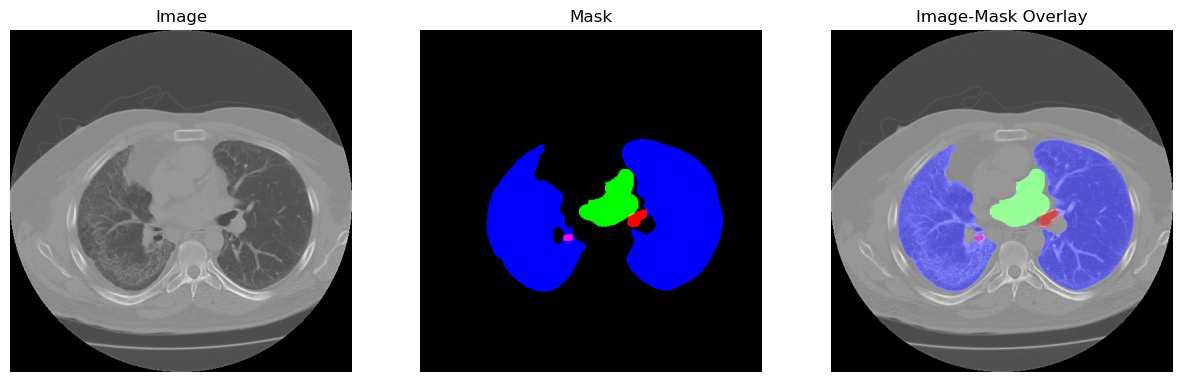

In [35]:
# Visualize the proper example
img, mask_rgb = proper_example
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

alpha = 0.5
overlay = cv2.addWeighted(img_rgb, 1, mask_rgb, alpha, 0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(mask_rgb)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Image-Mask Overlay")
plt.imshow(overlay)
plt.axis('off')
plt.show()


Con esta función se confirma los canales para cada etiqueta teniendo el mapeo como  Traquea: Rojo, Corazón: Verde y Pulmones: azul.